In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow as tf
import keras
from keras import ops
import random

from sklearn.preprocessing import MinMaxScaler
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR

import robot_vlp.data.preprocessing as p

%load_ext autoreload
%autoreload 2


2024-09-27 13:55:19.382 | INFO     | robot_vlp.config:<module>:11 - PROJ_ROOT path is: /Users/tyrelglass/PhD/Repositories/robot-vlp


In [12]:
with open(PROCESSED_DATA_DIR/'model_train_test_data.pickle', 'rb') as handle:
    data_dic = pickle.load(handle)

train_files = data_dic['train_files']
valid_files = data_dic['valid_files']
test_files = data_dic['test_files']

X_train_data = data_dic['X_train_data']
X_test_data = data_dic['X_test_data']
X_valid_data = data_dic['X_valid_data']

y_train_data = data_dic['y_train_data']
y_test_data = data_dic['y_test_data']
y_valid_data = data_dic['y_valid_data']

X_train = data_dic['X_test']
X_valid = data_dic['X_valid']
X_test = data_dic['X_test']

y_train = data_dic['y_test']
y_valid = data_dic['y_valid']
y_test = data_dic['y_test']


In [13]:
def ang_loss_fn(y_true, y_pred):
    return keras.losses.cosine_similarity(y_true, y_pred) + 1


input_ = keras.layers.Input(shape=(10, 5))
# hidden1 = keras.layers.SimpleRNN(30, return_sequences=True)(input_)
# hidden2 = keras.layers.SimpleRNN(30)(hidden1)
flat_input = keras.layers.Flatten()(input_)
hidden1 = keras.layers.Dense(10)(flat_input)
hidden2 = keras.layers.Dense(20)(hidden1)
out1 = keras.layers.Dense(1, name='loss1')(hidden2)
out2 = keras.layers.Dense(1, name='loss2')(hidden2)
out3 = keras.layers.Dense(2, name='loss3')(hidden2)

model = keras.Model(inputs = [input_], outputs = [out1,out2,out3])

model.compile(optimizer='adam',
              loss = ['mse','mse',ang_loss_fn],
            #   loss_weights = [1.],
              )

In [16]:
history = model.fit(
    x = X_train, 
    y = [y_train[:,0], y_train[:,1], p.ang_to_vector(y_train[:,2], unit = 'degrees').numpy()],
    epochs = 50,
    validation_data =    (X_valid, [y_valid[:,0], y_valid[:,1], p.ang_to_vector(y_valid[:,2], unit = 'degrees').numpy()])                               
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.5415 - loss1_loss: 4.5018 - loss2_loss: 1.3842 - loss3_loss: 0.6554 - val_loss: 0.5400 - val_loss1_loss: 0.1090 - val_loss2_loss: 0.1180 - val_loss3_loss: 0.3129
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - loss: 0.4516 - loss1_loss: 0.0940 - loss2_loss: 0.1019 - loss3_loss: 0.2557 - val_loss: 0.3020 - val_loss1_loss: 0.0932 - val_loss2_loss: 0.0793 - val_loss3_loss: 0.1293
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - loss: 0.2681 - loss1_loss: 0.0819 - loss2_loss: 0.0695 - loss3_loss: 0.1167 - val_loss: 0.2602 - val_loss1_loss: 0.0791 - val_loss2_loss: 0.0580 - val_loss3_loss: 0.1230
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - loss: 0.2281 - loss1_loss: 0.0699 - loss2_loss: 0.0544 - loss3_loss: 0.1038 - val_loss: 0.2075 - val_loss1_loss: 0.0693 - val_loss2_loss: 0.0467 - val_loss3_loss: 0.0914
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.1891 - loss1_loss: 0.0601 - loss2_

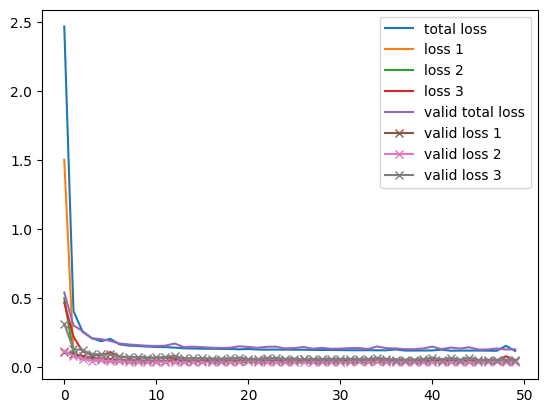

In [17]:
plt.plot(history.history['loss'], label = 'total loss')
plt.plot(history.history['loss1_loss'], label = 'loss 1')
plt.plot(history.history['loss2_loss'], label = 'loss 2')
plt.plot(history.history['loss3_loss'], label = 'loss 3')

plt.plot(history.history['val_loss'], label = 'valid total loss')
plt.plot(history.history['val_loss1_loss'],"-x", label = 'valid loss 1')
plt.plot(history.history['val_loss2_loss'],"-x", label = 'valid loss 2')
plt.plot(history.history['val_loss3_loss'],"-x",label = 'valid loss 3')
plt.legend()

In [19]:
from robot_vlp.config import MODELS_DIR

model.save(MODELS_DIR / 'model_01.keras')

In [384]:
# --------------------------Train RNN----------------------
model_rnn = keras.models.Sequential([
    keras.layers.Input([None, 5]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(3)
])

# losses = [
#     ang_loss_fn,
#     ang_loss_fn,
#     ang_loss_fn,
# ]
# model_rnn.compile(loss=losses,
#                   loss_weights = [1,1,1], optimizer="adam")
# history = model_rnn.fit(X_test, y_test, epochs=500, verbose= None)
# # pd.DataFrame(history.history).plot()